In [2]:
#%% Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram


#%% Criando o DataFrame

dados = pd.DataFrame({
    'estudante': ['Ana', 'Bruno', 'Carla', 'Diego', 'Elisa'],
    'teoria': [8.5, 6.0, 9.0, 4.5, 7.0],
    'prática': [8.0, 5.5, 9.5, 5.0, 6.5],
    'projeto': [7.5, 6.5, 8.5, 4.0, 7.0]
})

dados

,estudante,teoria,prática,projeto
0,Ana,8.5,8.0,7.5
1,Bruno,6.0,5.5,6.5
2,Carla,9.0,9.5,8.5
3,Diego,4.5,5.0,4.0
4,Elisa,7.0,6.5,7.0


In [3]:
#%% Selecionando as variáveis para clusterização

dados_cluster = dados[['teoria', 'prática', 'projeto']]

dados_cluster

,teoria,prática,projeto
0,8.5,8.0,7.5
1,6.0,5.5,6.5
2,9.0,9.5,8.5
3,4.5,5.0,4.0
4,7.0,6.5,7.0


In [5]:
#%% Cluster Hierárquico - Average Linkage

cluster_avg = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='average'
)

indica_cluster_avg = cluster_avg.fit_predict(dados_cluster)

dados['cluster_average'] = indica_cluster_avg
dados['cluster_average'] = dados['cluster_average'].astype('category')

dados

,estudante,teoria,prática,projeto,cluster_average
0,Ana,8.5,8.0,7.5,0
1,Bruno,6.0,5.5,6.5,1
2,Carla,9.0,9.5,8.5,0
3,Diego,4.5,5.0,4.0,2
4,Elisa,7.0,6.5,7.0,1


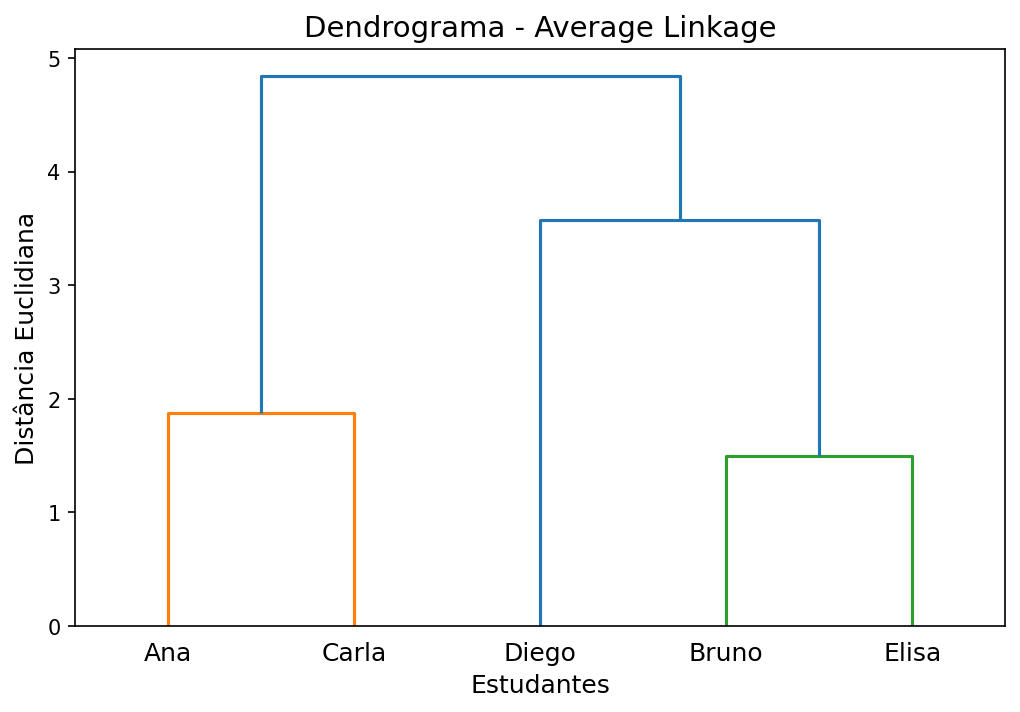

In [6]:
#%% Dendrograma - Average Linkage

Z_avg = linkage(dados_cluster, method='average', metric='euclidean')

plt.figure(figsize=(8, 5), dpi=150)

dendrogram_a = dendrogram(
    Z_avg,
    labels=dados['estudante'].values
)

plt.title('Dendrograma - Average Linkage', fontsize=14)
plt.xlabel('Estudantes', fontsize=12)
plt.ylabel('Distância Euclidiana', fontsize=12)
plt.show()

In [7]:
#%% Coeficientes do esquema hierárquico de aglomeração

coef_avg = [y[1] for y in dendrogram_a['dcoord']]

print(coef_avg)

[np.float64(1.8708286933869707), np.float64(1.5), np.float64(3.570670012110093), np.float64(4.840246695493289)]


In [9]:
#%% Cluster Não Hierárquico K-means

kmeans = KMeans(
    n_clusters=3,
    init='random',
    random_state=100,
    n_init=10
).fit(dados_cluster)

kmeans_clusters = kmeans.labels_

dados['cluster_kmeans'] = kmeans_clusters
dados['cluster_kmeans'] = dados['cluster_kmeans'].astype('category')

dados

C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,estudante,teoria,prática,projeto,cluster_average,cluster_kmeans
0,Ana,8.5,8.0,7.5,0,0
1,Bruno,6.0,5.5,6.5,1,2
2,Carla,9.0,9.5,8.5,0,0
3,Diego,4.5,5.0,4.0,2,1
4,Elisa,7.0,6.5,7.0,1,2


In [10]:
#%% Identificando as coordenadas dos centróides finais

cent_finais = pd.DataFrame(kmeans.cluster_centers_)

cent_finais.columns = dados_cluster.columns
cent_finais.index.name = 'cluster'

cent_finais

,teoria,prática,projeto
cluster,,,
0,8.75,8.75,8.00
1,4.50,5.00,4.00
2,6.50,6.00,6.75


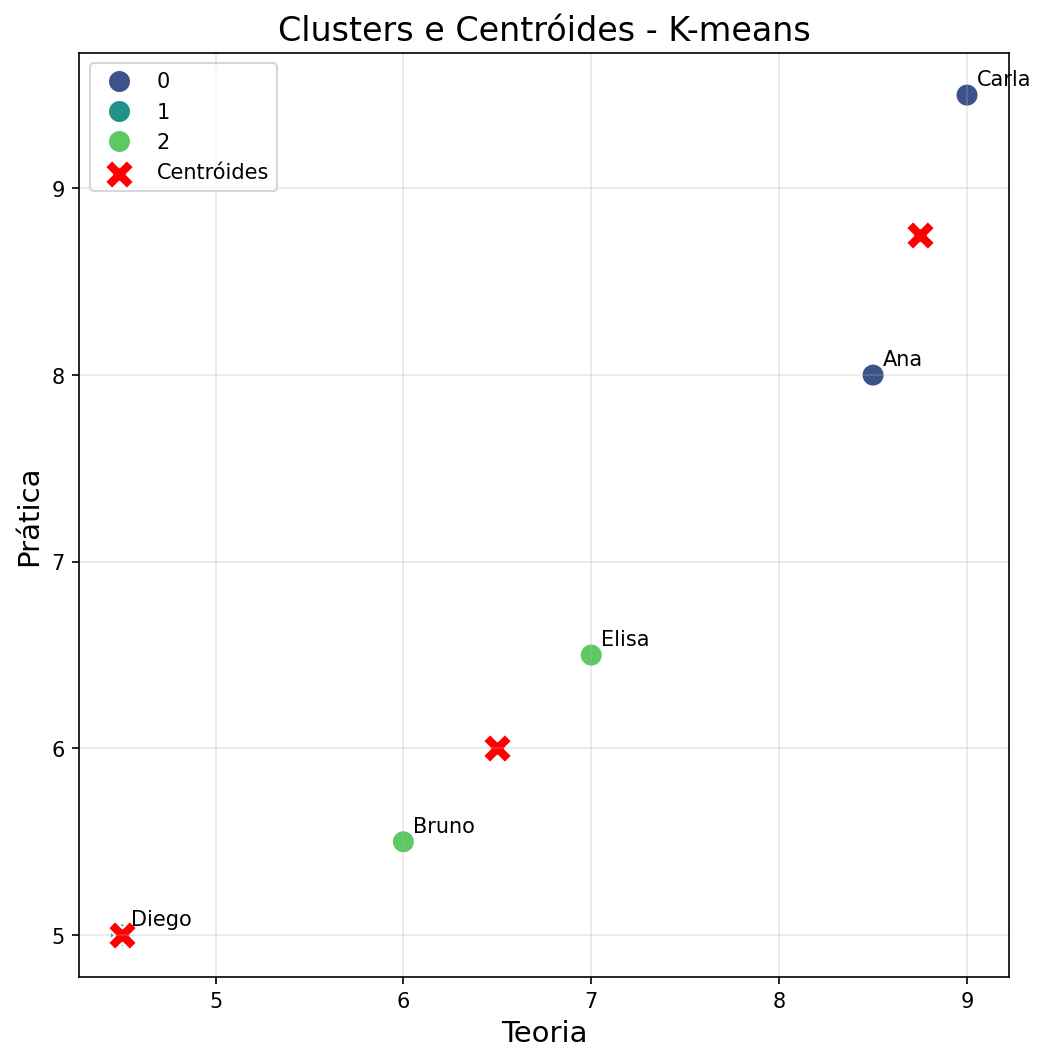

In [11]:
#%% Plotando as observações e seus centróides dos clusters

plt.figure(figsize=(8, 8), dpi=150)

sns.scatterplot(
    data=dados,
    x='teoria',
    y='prática',
    hue='cluster_kmeans',
    palette='viridis',
    s=120
)

sns.scatterplot(
    data=cent_finais,
    x='teoria',
    y='prática',
    color='red',
    label='Centróides',
    marker='X',
    s=200
)

# Adicionando o nome dos estudantes no gráfico
for i in range(dados.shape[0]):
    plt.text(
        dados['teoria'][i] + 0.05,
        dados['prática'][i] + 0.05,
        dados['estudante'][i],
        fontsize=10
    )

plt.title('Clusters e Centróides - K-means', fontsize=16)
plt.xlabel('Teoria', fontsize=14)
plt.ylabel('Prática', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()